# CatBoost GPU + Optuna — GeoATM Popularity

**Данные:** `data/train_data_v2.csv` (6200 строк, ~134 признака)  
**Модель:** CatBoostRegressor на GPU  
**Подбор гиперпараметров:** Optuna (100 trials)  
**Метрика:** RMSE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from catboost import CatBoostRegressor, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
DATA_PATH = Path('../data/train_data_v2.csv')
TARGET = 'target'
MODEL_SAVE_PATH = Path('../models/catboost_gpu_optuna.cbm')

pd.set_option('display.float_format', '{:.4f}'.format)
print('OK')

OK


## 1. Загрузка данных

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(df[TARGET].describe())

Shape: (6200, 134)
count   6200.0000
mean       0.0008
std        0.0859
min       -0.1450
25%       -0.0612
50%       -0.0155
75%        0.0402
max        0.2186
Name: target, dtype: float64


## 2. Определение признаков

In [3]:
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m',
    'nearest_subway_dist_m', 'nearest_post_offices_dist_m',
    'nearest_offices_dist_m', 'nearest_shops_food_small_dist_m',
    'nearest_fitness_sport_dist_m', 'nearest_hotels_hostels_dist_m',
    'land_use_dist_m', 'city_center_dist_m', 'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m',
    'count_pharmacies_hospitals_300m', 'count_banks_atms_300m',
    'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m',
    'count_education_300m', 'count_post_offices_300m',
    'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m',
    'count_hypermarkets_300m', 'count_markets_300m',
    'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'population', 'avg_income_q3_2025_rub',
]

CATEGORICAL_FEATURES = [
    'federal_district', 'city_size_category', 'land_use_type', 'atm_group',
]

ALL_FEATURES = BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES + CATEGORICAL_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f'Итого признаков: {len(ALL_FEATURES)}')


Итого признаков: 66


## 3. Подготовка данных

In [4]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].astype(float)

# bool → int
for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

# Дистанции: log1p
for col in DISTANCE_FEATURES:
    if col in X.columns:
        X[col] = np.log1p(X[col])

# Категориальные: NaN → 'unknown', str dtype (CatBoost обрабатывает нативно)
cat_cols = [f for f in CATEGORICAL_FEATURES if f in X.columns]
for col in cat_cols:
    X[col] = X[col].fillna('unknown').astype(str)

# Стратификация по city_size_category
strat_col = df['city_size_category'].fillna('unknown')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=strat_col
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target: mean={y_train.mean():.4f}, std={y_train.std():.4f}')
print(f'Test  target: mean={y_test.mean():.4f}, std={y_test.std():.4f}')

Train: (4960, 66), Test: (1240, 66)
Train target: mean=0.0011, std=0.0856
Test  target: mean=-0.0001, std=0.0873


## 4. CatBoost Pool

In [5]:
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_cols)
print(f'Cat features ({len(cat_cols)}): {cat_cols}')

Cat features (4): ['federal_district', 'city_size_category', 'land_use_type', 'atm_group']


## 5. Baseline CatBoost GPU

In [6]:
cb_baseline = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    task_type='GPU',
    random_seed=RANDOM_STATE,
    eval_metric='RMSE',
    verbose=100,
)
cb_baseline.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)

y_pred_base = cb_baseline.predict(X_test)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)
r2_base   = r2_score(y_test, y_pred_base)
print(f'\nBaseline  RMSE={rmse_base:.4f}  MAE={mae_base:.4f}  R²={r2_base:.4f}')

0:	learn: 0.0828545	test: 0.0845086	best: 0.0845086 (0)	total: 4.05s	remaining: 1h 7m 24s
100:	learn: 0.0448209	test: 0.0467020	best: 0.0467020 (100)	total: 6s	remaining: 53.4s
200:	learn: 0.0422717	test: 0.0459266	best: 0.0459246 (199)	total: 7.76s	remaining: 30.8s
300:	learn: 0.0404122	test: 0.0455457	best: 0.0455419 (299)	total: 9.41s	remaining: 21.9s
400:	learn: 0.0391298	test: 0.0454629	best: 0.0454375 (374)	total: 11.2s	remaining: 16.8s
500:	learn: 0.0381992	test: 0.0454005	best: 0.0453918 (450)	total: 13.2s	remaining: 13.1s
bestTest = 0.04539176788
bestIteration = 450
Shrink model to first 451 iterations.

Baseline  RMSE=0.0454  MAE=0.0362  R²=0.7292


## 6. Optuna — подбор гиперпараметров (100 trials)

In [7]:
def objective(trial):
    params = {
        'iterations':          1000,
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth':               trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':     trial.suggest_float('random_strength', 0.0, 2.0),
        'border_count':        trial.suggest_int('border_count', 32, 128),  # GPU max=128
        'task_type':           'GPU',
        'random_seed':         RANDOM_STATE,
        'eval_metric':         'RMSE',
        'verbose':             False,
        'early_stopping_rounds': 50,
    }
    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=test_pool)
    pred = model.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, pred))

study = optuna.create_study(direction='minimize', study_name='catboost_gpu')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest RMSE: {study.best_value:.4f}')
print('Best params:', study.best_params)

Best trial: 45. Best value: 0.0444154: 100%|██████████| 100/100 [49:17<00:00, 29.57s/it] 


Best RMSE: 0.0444
Best params: {'learning_rate': 0.04272905523365136, 'depth': 10, 'l2_leaf_reg': 8.057372685463006, 'bagging_temperature': 0.8024114699720122, 'random_strength': 0.1397526978607622, 'border_count': 86}


## 7. Финальная модель с лучшими параметрами

In [8]:
best_params = dict(study.best_params)
best_params.update({
    'iterations':            2000,
    'task_type':             'GPU',
    'random_seed':           RANDOM_STATE,
    'eval_metric':           'RMSE',
    'verbose':               100,
})

cb_final = CatBoostRegressor(**best_params)
cb_final.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)

y_pred_final = cb_final.predict(X_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final  = mean_absolute_error(y_test, y_pred_final)
r2_final   = r2_score(y_test, y_pred_final)
print(f'\nFinal     RMSE={rmse_final:.4f}  MAE={mae_final:.4f}  R²={r2_final:.4f}')
print(f'Baseline  RMSE={rmse_base:.4f}')
print(f'Δ RMSE = {rmse_base - rmse_final:+.4f}')

0:	learn: 0.0832028	test: 0.0848534	best: 0.0848534 (0)	total: 57.6ms	remaining: 1m 55s
100:	learn: 0.0440459	test: 0.0464894	best: 0.0464894 (100)	total: 5.55s	remaining: 1m 44s
200:	learn: 0.0407612	test: 0.0455388	best: 0.0455388 (200)	total: 11.3s	remaining: 1m 40s
300:	learn: 0.0383200	test: 0.0450981	best: 0.0450914 (298)	total: 16.9s	remaining: 1m 35s
400:	learn: 0.0364290	test: 0.0448021	best: 0.0447963 (394)	total: 22.6s	remaining: 1m 30s
500:	learn: 0.0346093	test: 0.0446367	best: 0.0446122 (494)	total: 28.3s	remaining: 1m 24s
600:	learn: 0.0332687	test: 0.0445317	best: 0.0445248 (595)	total: 34s	remaining: 1m 19s
700:	learn: 0.0320976	test: 0.0444352	best: 0.0444314 (698)	total: 39.7s	remaining: 1m 13s
bestTest = 0.04441534653
bestIteration = 719
Shrink model to first 720 iterations.

Final     RMSE=0.0444  MAE=0.0354  R²=0.7408
Baseline  RMSE=0.0454
Δ RMSE = +0.0010


## 8. Важность признаков

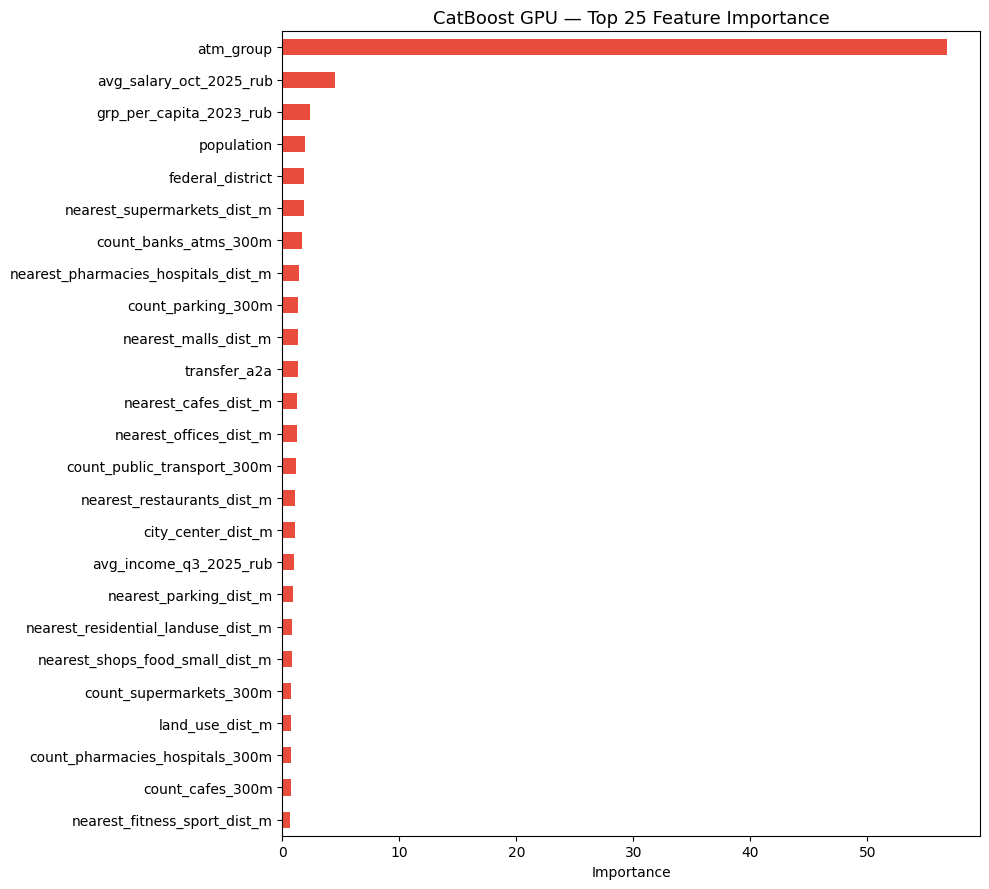


Top 15 features:
atm_group                             56.7762
avg_salary_oct_2025_rub                4.4968
grp_per_capita_2023_rub                2.3988
population                             1.9650
federal_district                       1.8830
nearest_supermarkets_dist_m            1.8451
count_banks_atms_300m                  1.7060
nearest_pharmacies_hospitals_dist_m    1.4250
count_parking_300m                     1.3535
nearest_malls_dist_m                   1.3441
transfer_a2a                           1.2952
nearest_cafes_dist_m                   1.2379
nearest_offices_dist_m                 1.2263
count_public_transport_300m            1.1355
nearest_restaurants_dist_m             1.0894


In [9]:
feat_imp = pd.Series(
    cb_final.get_feature_importance(),
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
median_imp = feat_imp.median()
colors = ['#e74c3c' if v > median_imp else '#3498db' for v in feat_imp.head(25).values[::-1]]
feat_imp.head(25).iloc[::-1].plot.barh(ax=ax, color=colors)
ax.set_title('CatBoost GPU — Top 25 Feature Importance', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 15 features:')
print(feat_imp.head(15).to_string())

## 9. Сохранение модели

In [11]:
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
cb_final.save_model(str(MODEL_SAVE_PATH))
print(f'Model saved → {MODEL_SAVE_PATH}')


Model saved → ..\models\catboost_gpu_optuna.cbm
